# from torchvision.transforms import v2 的使用示例
## 1.从图片到tv_tensor,数据增强，保存图像
## 要绘制图像就需要np

<class 'torch.Tensor'> torch.uint8 torch.Size([3, 320, 426])
<class 'torchvision.tv_tensors._image.Image'> torch.uint8 torch.Size([3, 320, 426])


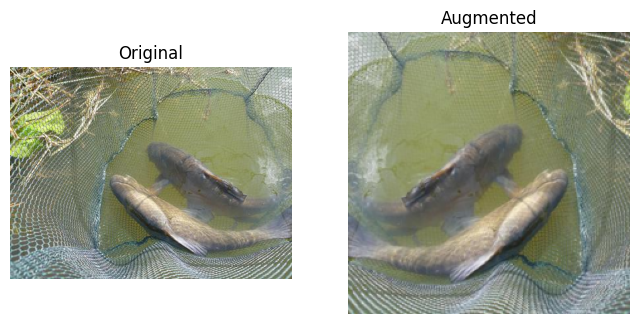

In [6]:
import torch
from torchvision.io import read_image
from torchvision import tv_tensors
from torchvision.transforms import v2
from torchvision.utils import save_image

import matplotlib.pyplot as plt


# 1 读取图像
img = read_image(
    "/home/xiaopangdun/project/deep_learning/src/train/datasets/IMAGENETTE/imagenette2-320/train/n01440764/ILSVRC2012_val_00000293.JPEG"
)

print(type(img), img.dtype, img.shape)

# 2 转 tv_tensor
img_tv = tv_tensors.Image(img)
print(type(img_tv), img_tv.dtype, img_tv.shape)

# 3 数据增强
transform = v2.Compose(
    [
        v2.RandomResizedCrop(224),
        v2.RandomHorizontalFlip(p=1.0),
    ]
)

# 4 执行增强
img_tv_aug = transform(img_tv)

# 5 保存图片
img_save = img_tv_aug.to(torch.float32) / 255.0
save_image(img_save, "../augmented.jpg")

# 5 可视化
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(img.permute(1, 2, 0))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_tv_aug.permute(1, 2, 0))
plt.title("Augmented")
plt.axis("off")

plt.show()

<class 'numpy.ndarray'> uint8 (224, 224, 3)


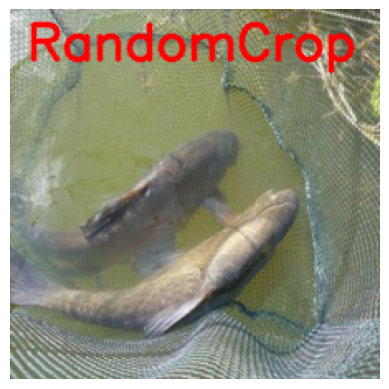

In [8]:
import cv2
img_np = img_tv_aug.permute(1,2,0).cpu().numpy().copy()
print(type(img_np), img_np.dtype, img_np.shape)
cv2.putText(
    img_np,
    "RandomCrop + Flip",
    (10,30),
    cv2.FONT_HERSHEY_SIMPLEX,
    1,
    (255,0,0),
    2,
    cv2.LINE_AA
)
plt.imshow(img_np)
plt.axis("off")
plt.show()

In [ ]:
from torchvision.transforms import v2

transform = v2.Compose([
    v2.RandomResizedCrop(224),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [ ]:
img_aug = transform(img)

mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
std = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

img_vis = img_aug * std + mean
img_vis = img_vis.clamp(0,1)

plt.imshow(img_vis.permute(1,2,0))
plt.axis("off")